<a href="https://colab.research.google.com/github/mohamed8348/LEGAL_CONTRACT_CLASSIFIER/blob/main/data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymupdf -q

In [ ]:
import os
import fitz
import pandas as pd

In [ ]:
pdf_files = sorted([f for f in os.listdir() if f.endswith(".pdf")])

print("Total PDFs:", len(pdf_files))
print(pdf_files[:5])

Total PDFs: 100
['Contract_001.pdf', 'Contract_002.pdf', 'Contract_003.pdf', 'Contract_004.pdf', 'Contract_005.pdf']


In [ ]:
contracts = []

for pdf in pdf_files:

    doc = fitz.open(pdf)

    text = ""

    for page in doc:
        text += page.get_text()

    contracts.append({
        "file_name": pdf,
        "contract_text": text
    })

In [ ]:
df = pd.DataFrame(contracts)

df.head()

,file_name,contract_text
0,Contract_001.pdf,EMPLOYMENT AGREEMENT BETWEEN NORTHGATE\nTECHNO...
1,Contract_002.pdf,EMPLOYMENT AGREEMENT BETWEEN IRONBRIDGE LTD.\n...
2,Contract_003.pdf,EMPLOYMENT AGREEMENT BETWEEN FERNBROOK INC.\nA...
3,Contract_004.pdf,EMPLOYMENT AGREEMENT BETWEEN IRONBRIDGE LTD.\n...
4,Contract_005.pdf,EMPLOYMENT AGREEMENT BETWEEN WILLOWBROOK LLC\n...


In [ ]:
print(df.shape)

df.info()

(100, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_name      100 non-null    object
 1   contract_text  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
print(df["contract_text"][0])

EMPLOYMENT AGREEMENT BETWEEN NORTHGATE
TECHNOLOGIES LTD. AND CLARA LARKIN
Contract ID: CTR-EMP-001  |  Contract Type: Employment Agreement  |  Risk Classification (dataset label):
Medium
Agreement Date: October 07, 2025
Effective Date:
October 07, 2025
Expiry Date:
January 05, 2026
Governing State:
New York
6. Party Details
Employer (Party A)
Employee (Party B)
Northgate Technologies Ltd.
Clara Larkin
6492 Elmswood Avenue, Kingsford, Florida 94259
2350 Fernbrook Drive, Elmswood, Virginia 28301
Phone: +1-452-962-9830
Phone: +1-469-964-8019
Email: northgate.technologies.ltd.75@swiftmail.example
Email: clara.larkin47@workline.example
Authorized Representative: Vikram Osei
Authorized Representative: Clara Larkin
8. Definitions
"Agreement" means this Employment Agreement together with all schedules and annexures hereto. "Employer"
refers to Northgate Technologies Ltd., and "Employee" refers to Clara Larkin, individually a "Party" and
collectively the "Parties". "Effective Date" means Octobe

In [ ]:
def extract_contract_type(text):

    text = text.upper()

    if "EMPLOYMENT AGREEMENT" in text:
        return "Employment"

    elif "INTERNSHIP AGREEMENT" in text:
        return "Internship"

    elif "LEASE AGREEMENT" in text or "RENTAL AGREEMENT" in text:
        return "Lease"

    elif "FREELANCE AGREEMENT" in text:
        return "Freelance"

    elif "PURCHASE AGREEMENT" in text:
        return "Purchase"

    elif "SERVICE AGREEMENT" in text:
        return "Service"

    elif "VENDOR AGREEMENT" in text:
        return "Vendor"

    elif "CONSULTING AGREEMENT" in text:
        return "Consulting"

    elif "NON-DISCLOSURE AGREEMENT" in text or "NON DISCLOSURE AGREEMENT" in text or "NDA" in text:
        return "NDA"

    else:
        return "Other"

In [ ]:
df["contract_type"] = df["contract_text"].apply(extract_contract_type)

df["contract_type"].value_counts()

,count
contract_type,
Lease,20
Employment,10
NDA,10
Service,10
Vendor,10
Purchase,10
Internship,10
Freelance,10
Consulting,10


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (100, 3)


In [ ]:
df.columns

Index(['file_name', 'contract_text', 'contract_type'], dtype='object')

In [ ]:
df.dtypes

,0
file_name,object
contract_text,object
contract_type,object


In [ ]:
df.isnull().sum()

,0
file_name,0
contract_text,0
contract_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["contract_type"].value_counts()

,count
contract_type,
Lease,20
Employment,10
NDA,10
Service,10
Vendor,10
Purchase,10
Internship,10
Freelance,10
Consulting,10


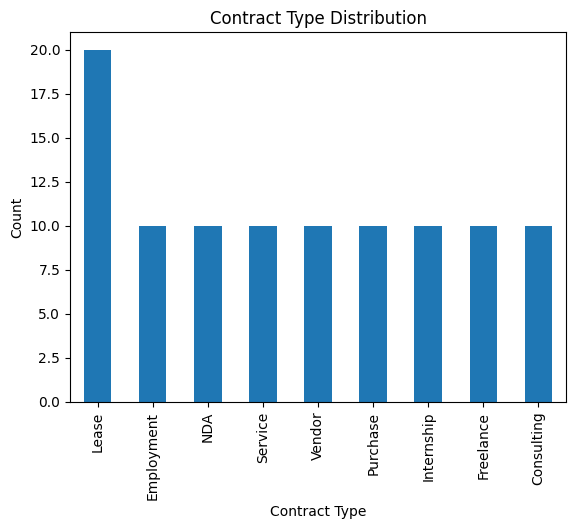

In [ ]:
import matplotlib.pyplot as plt

df["contract_type"].value_counts().plot(kind="bar")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.show()

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 3. Remove punctuation & special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenize
    words = text.split()

    # 5. Remove stopwords
    words = [word for word in words if word not in stop_words]

    # 6. Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # 7. Join words
    return " ".join(words)

In [ ]:
df["clean_text"] = df["contract_text"].apply(preprocess_text)

In [ ]:
df[["contract_text", "clean_text"]].head()

,contract_text,clean_text
0,EMPLOYMENT AGREEMENT BETWEEN NORTHGATE\nTECHNO...,employment agreement northgate technology ltd ...
1,EMPLOYMENT AGREEMENT BETWEEN IRONBRIDGE LTD.\n...,employment agreement ironbridge ltd nathaniel ...
2,EMPLOYMENT AGREEMENT BETWEEN FERNBROOK INC.\nA...,employment agreement fernbrook inc daniel call...
3,EMPLOYMENT AGREEMENT BETWEEN IRONBRIDGE LTD.\n...,employment agreement ironbridge ltd adrian iye...
4,EMPLOYMENT AGREEMENT BETWEEN WILLOWBROOK LLC\n...,employment agreement willowbrook llc neha iyer...


In [ ]:
df.to_csv("cleaned_contract_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("cleaned_contract_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df["clean_text"]

y = df["contract_type"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [ ]:
print(X.shape)

(100, 996)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [ ]:
print(X_train.shape)

print(X_test.shape)

(80, 996)
(20, 996)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

Accuracy : 0.6


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))

Accuracy : 0.35


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

Accuracy : 1.0


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))

Accuracy : 1.0


In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Naive Bayes",

        "Random Forest",

        "SVM"

    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_lr),

        accuracy_score(y_test,y_pred_nb),

        accuracy_score(y_test,y_pred_rf),

        accuracy_score(y_test,y_pred_svm)

    ]

})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
3,SVM,1.00
2,Random Forest,1.00
0,Logistic Regression,0.60
1,Naive Bayes,0.35


In [ ]:
from sklearn.metrics import precision_score

y_pred_best = y_pred_rf
print("Precision:", precision_score(y_test, y_pred_best, average="weighted"))

Precision: 1.0


In [ ]:
from sklearn.metrics import recall_score

print("Recall:", recall_score(y_test, y_pred_best, average="weighted"))

Recall: 1.0


In [ ]:
from sklearn.metrics import f1_score

print("F1 Score:", f1_score(y_test, y_pred_best, average="weighted"))

F1 Score: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



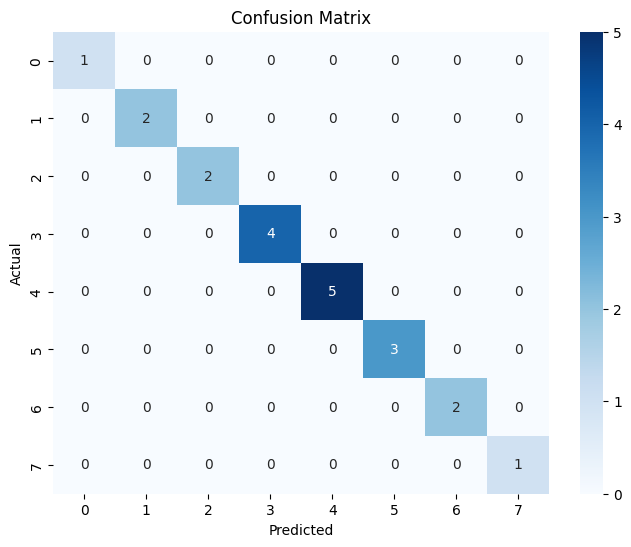

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Average Accuracy: 1.0


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'n_estimators': 100}
1.0


In [ ]:
import joblib

best_model = grid.best_estimator_
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [ ]:
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [ ]:
model = joblib.load("best_model.pkl")

sample = [
    "Employee must maintain confidentiality and follow company policies."
]

sample = tfidf.transform(sample)

prediction = model.predict(sample)

print(label_encoder.inverse_transform(prediction))

[4]


In [ ]:
best_model = svm

In [ ]:
scores = cross_val_score(best_model, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[1.   1.   0.95 0.9  1.  ]
Average Accuracy: 0.97
